# Thesis Notebook 13 — Architecture Progression & HPO Analysis

**Purpose:** Analyse the DL architecture progression (Flat → Fusion → Gated → Attention) and the effect of
Hyperparameter Optimisation (HPO) on both the final CatBoost and Attention DL models.

**Key thesis claim:** HPO modestly improved both finalists (+0.004 avg R² for CatBoost, +0.005 for Attention DL)
but did not change the ML-vs-DL conclusion. Architecture complexity adds measurable value on test.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO = Path().resolve().parent
DL_DIR = REPO / 'results' / 'dl_metrics'
ML_DIR = REPO / 'results' / 'metrics' / 'thesis_ml_test'
HPO_DIR = REPO / 'results' / 'hpo'
FIGS = REPO / 'results' / 'figures' / 'thesis'
FIGS.mkdir(parents=True, exist_ok=True)

TARGETS = ['valence', 'energy', 'danceability', 'popularity']
TARGET_LABELS = ['Valence', 'Energy', 'Danceability', 'Popularity']

# Architecture display order
ARCH_ORDER = [
    'FlatAllMLP',
    'MultiModalFusionMLP',
    'TaskGatedFusionMLP',
    'AttentionTaskGatedFusionMLP',
    'TaskGatedFusionMLP_FeatEng',
]
ARCH_LABELS = [
    'Flat MLP',
    'Multimodal Fusion',
    'Task-Gated Fusion',
    'Attention Task-Gated',
    'Task-Gated + FeatEng',
]

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})

C_VAL  = '#6366F1'  # indigo — validation
C_TEST = '#0EA5E9'  # sky blue — test
C_ML   = '#2563EB'  # blue — CatBoost
C_DL   = '#DC2626'  # red  — Attention DL
print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
# DL validation results (architecture selection)
dl_val = pd.read_csv(DL_DIR / 'thesis_val' / 'thesis_architecture_comparison_val_20260525_175338.csv')

# DL test results — all 5 architectures (default)
dl_test_all = pd.read_csv(DL_DIR / 'final_dl_test_20260601_212018.csv')

# DL test results — AttentionDL tuned
dl_test_tuned = pd.read_csv(DL_DIR / 'final_dl_test_20260601_224941.csv')

# ML test results — all families
ml_all = pd.read_csv(ML_DIR / 'thesis_ml_results_test_20260528_230741.csv')

# ML test results — CatBoost tuned
ml_tuned = pd.read_csv(ML_DIR / 'thesis_ml_results_test_20260601_160912.csv')

# HPO results
with open(HPO_DIR / 'catboost_best_params.json') as f:
    cb_hpo = json.load(f)
with open(HPO_DIR / 'attention_dl_best_params.json') as f:
    dl_hpo = json.load(f)

# CatBoost HPO trial histories
cb_trial_files = {
    'valence':      'catboost_hpo_val_valence_20260526_134225.csv',
    'energy':       'catboost_hpo_val_energy_20260527_005256.csv',
    'danceability': 'catboost_hpo_val_danceability_20260527_122726.csv',
    'popularity':   'catboost_hpo_val_popularity_20260527_221050.csv',
}
cb_trials = {t: pd.read_csv(HPO_DIR / f) for t, f in cb_trial_files.items()}

# AttentionDL HPO trial history
dl_trials = pd.read_csv(HPO_DIR / 'attention_dl_hpo_val_20260528_063616.csv')

print('DL val shape:', dl_val.shape)
print('DL test (all) shape:', dl_test_all.shape)
print('CatBoost HPO target samples:', {t: len(df) for t, df in cb_trials.items()})
print('AttentionDL HPO trials:', len(dl_trials))

DL val shape: (20, 11)
DL test (all) shape: (20, 11)
CatBoost HPO target samples: {'valence': 12, 'energy': 12, 'danceability': 12, 'popularity': 12}
AttentionDL HPO trials: 20


## 2. Figure 1 — DL Architecture Progression (Val vs Test R² by Target)

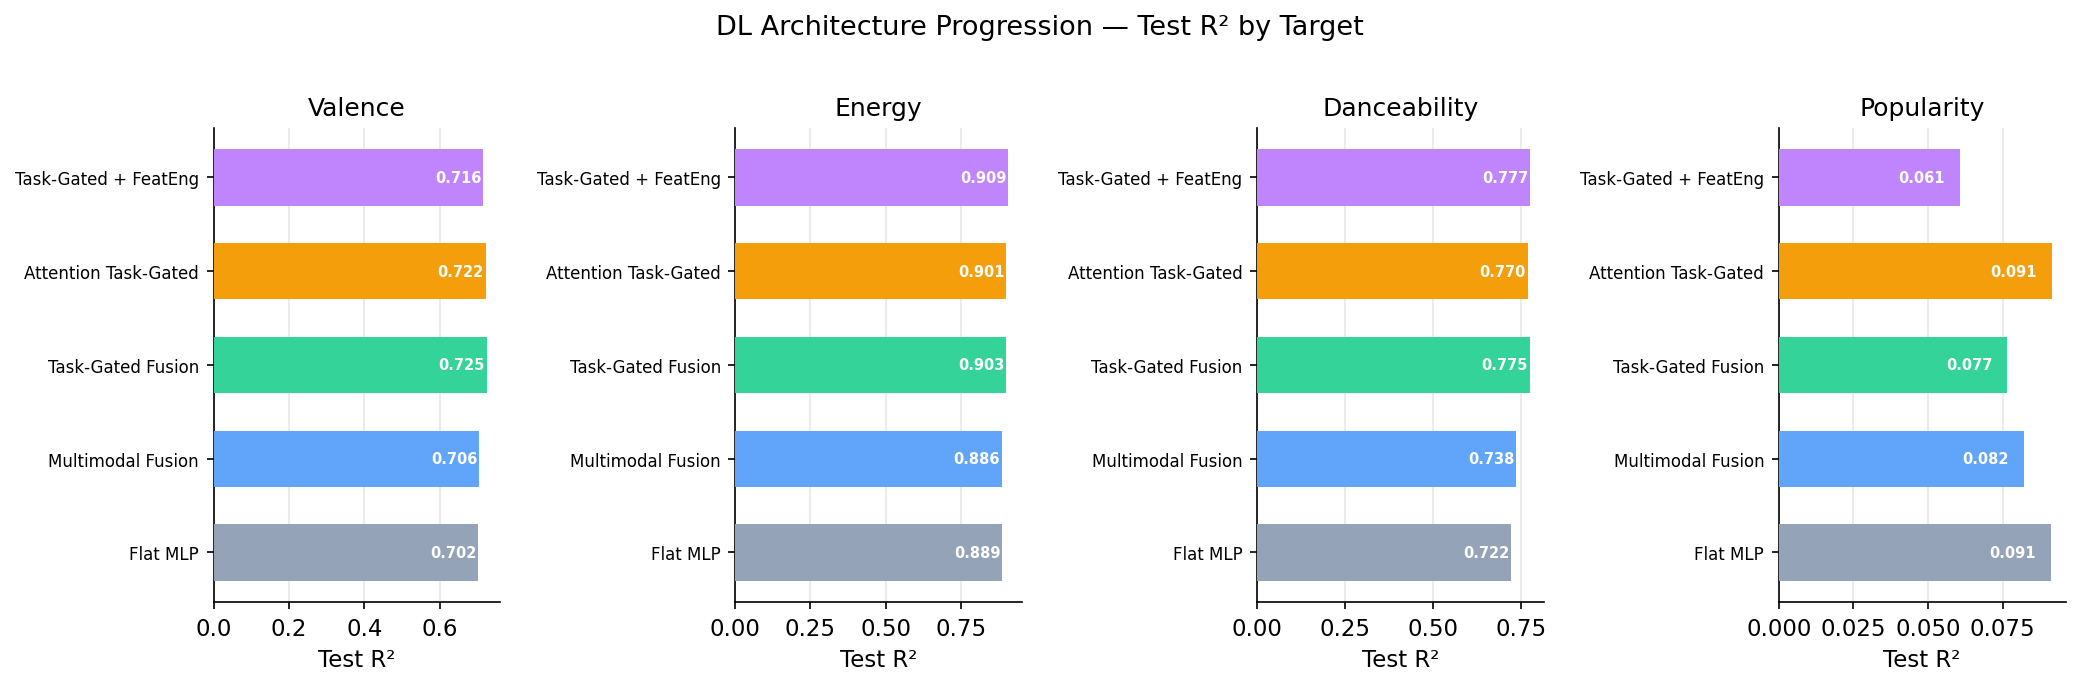

Saved: 13_dl_architecture_progression.png


In [3]:
# Normalise column names and target strings
for df in [dl_val, dl_test_all, dl_test_tuned]:
    df['target'] = df['target'].str.lower()
    df['model']  = df['model'].str.strip()

fig, axes = plt.subplots(1, 4, figsize=(14, 4.5), sharey=False)

palette_arch = {
    arch: c for arch, c in zip(
        ARCH_ORDER,
        ['#94A3B8', '#60A5FA', '#34D399', '#F59E0B', '#C084FC']
    )
}

for ax, tgt, tgt_label in zip(axes, TARGETS, TARGET_LABELS):
    test_r2 = []
    for arch in ARCH_ORDER:
        row = dl_test_all[(dl_test_all['model'] == arch) & (dl_test_all['target'] == tgt)]
        test_r2.append(row['r2'].values[0] if len(row) else np.nan)
    
    y = np.arange(len(ARCH_ORDER))
    colors = [palette_arch[a] for a in ARCH_ORDER]
    bars = ax.barh(y, test_r2, color=colors, height=0.6, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(ARCH_LABELS, fontsize=8)
    ax.set_xlabel('Test R²')
    ax.set_title(tgt_label)
    ax.grid(axis='x', alpha=0.3, zorder=0)
    for bar, val in zip(bars, test_r2):
        ax.text(val - 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', ha='right', va='center', fontsize=7, color='white', fontweight='bold')

fig.suptitle('DL Architecture Progression — Test R² by Target', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / '13_dl_architecture_progression.png', bbox_inches='tight')
plt.show()
print('Saved: 13_dl_architecture_progression.png')

## 3. Figure 2 — Validation vs Test R²: All 5 DL Architectures

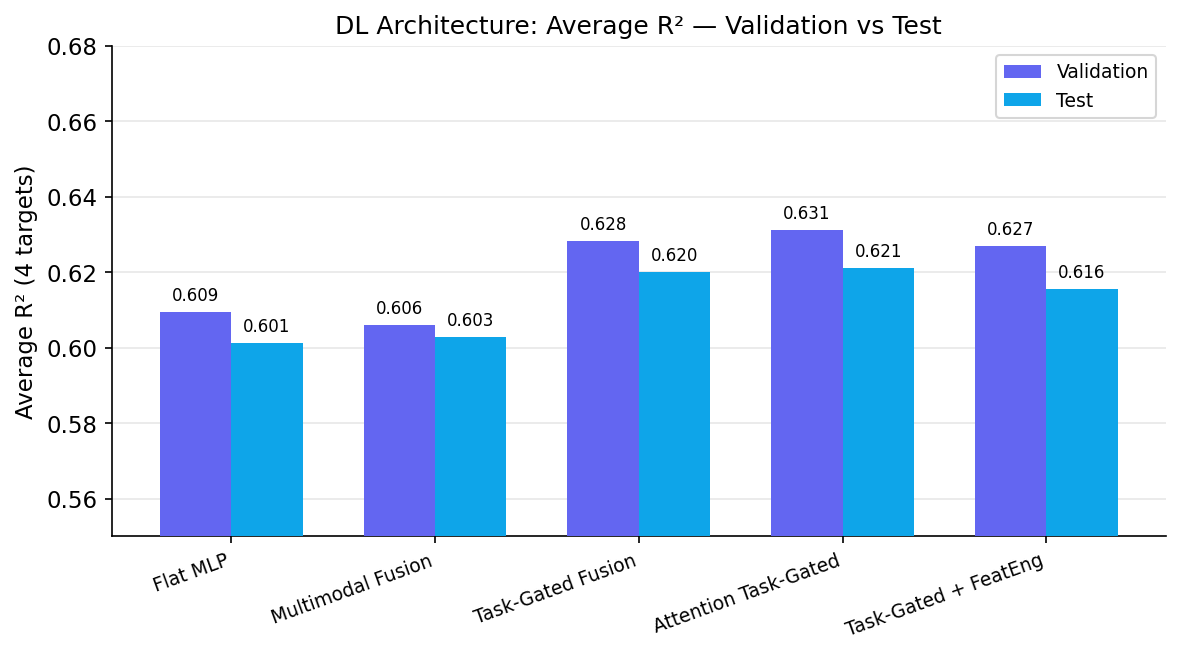

Saved: 13_val_vs_test_dl_architectures.png


In [4]:
# Average R² per architecture across 4 targets
arch_val_avg  = dl_val.groupby('model')['r2'].mean().reindex(ARCH_ORDER)
arch_test_avg = dl_test_all.groupby('model')['r2'].mean().reindex(ARCH_ORDER)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(ARCH_ORDER))
w = 0.35
ax.bar(x - w/2, arch_val_avg.values,  w, label='Validation', color=C_VAL,  zorder=3)
ax.bar(x + w/2, arch_test_avg.values, w, label='Test',       color=C_TEST, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(ARCH_LABELS, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Average R² (4 targets)')
ax.set_title('DL Architecture: Average R² — Validation vs Test')
ax.legend()
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_ylim(0.55, 0.68)

for bars, vals in [(ax.patches[:len(ARCH_ORDER)], arch_val_avg.values),
                   (ax.patches[len(ARCH_ORDER):], arch_test_avg.values)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / '13_val_vs_test_dl_architectures.png', bbox_inches='tight')
plt.show()
print('Saved: 13_val_vs_test_dl_architectures.png')

## 4. Figure 3 — HPO Effect: CatBoost Default vs Tuned

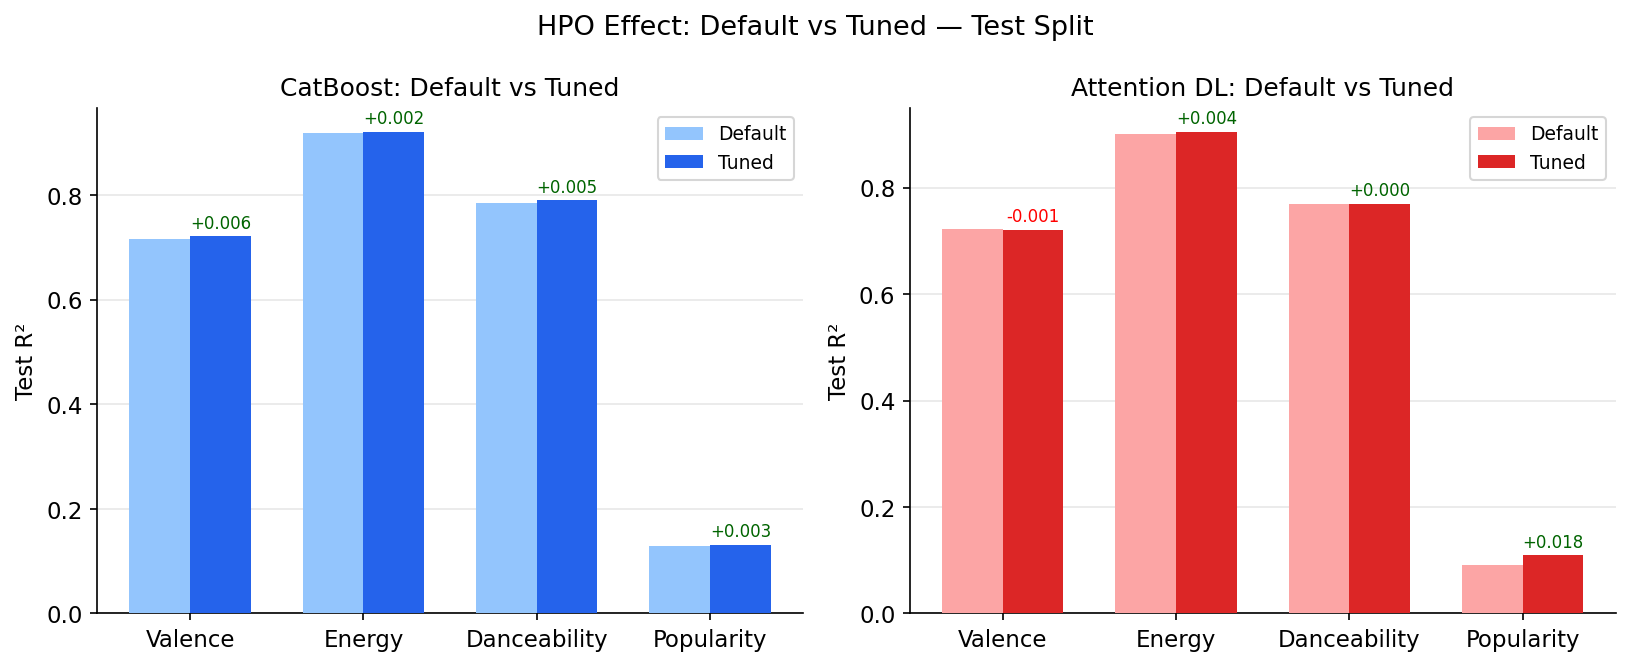

Saved: 13_hpo_effect_default_vs_tuned.png

=== HPO Effect Summary ===
CatBoost default avg R²: 0.6371
CatBoost tuned   avg R²: 0.6413  (gain: +0.0042)
AttentionDL default avg R²: 0.6212
AttentionDL tuned   avg R²: 0.6264  (gain: +0.0052)


In [5]:
ml_all['target'] = ml_all['target'].str.lower()
ml_tuned['target'] = ml_tuned['target'].str.lower()

cb_default = ml_all[ml_all['model'] == 'CatBoost'].set_index('target')['r2'].reindex(TARGETS)
cb_tuned   = ml_tuned[ml_tuned['model'] == 'CatBoost_tuned'].set_index('target')['r2'].reindex(TARGETS)
dl_default = dl_test_all[dl_test_all['model'] == 'AttentionTaskGatedFusionMLP'].set_index('target')['r2'].reindex(TARGETS)
dl_tuned_s = dl_test_tuned[dl_test_tuned['model'] == 'AttentionTaskGatedFusionMLP'].set_index('target')['r2'].reindex(TARGETS)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, default_vals, tuned_vals, title, c_d, c_t in [
    (axes[0], cb_default,   cb_tuned,   'CatBoost: Default vs Tuned', '#93C5FD', C_ML),
    (axes[1], dl_default,   dl_tuned_s, 'Attention DL: Default vs Tuned', '#FCA5A5', C_DL),
]:
    x = np.arange(len(TARGETS))
    w = 0.35
    bars_d = ax.bar(x - w/2, default_vals.values, w, label='Default', color=c_d, zorder=3)
    bars_t = ax.bar(x + w/2, tuned_vals.values,   w, label='Tuned',   color=c_t, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(TARGET_LABELS)
    ax.set_ylabel('Test R²')
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', alpha=0.3, zorder=0)
    # Annotate gain
    for xp, dv, tv in zip(x, default_vals.values, tuned_vals.values):
        gain = tv - dv
        ax.text(xp + w/2, tv + 0.008, f'{gain:+.3f}', ha='center', va='bottom',
                fontsize=8, color='darkgreen' if gain >= 0 else 'red')

plt.suptitle('HPO Effect: Default vs Tuned — Test Split', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / '13_hpo_effect_default_vs_tuned.png', bbox_inches='tight')
plt.show()
print('Saved: 13_hpo_effect_default_vs_tuned.png')

print('\n=== HPO Effect Summary ===')
print(f'CatBoost default avg R²: {cb_default.mean():.4f}')
print(f'CatBoost tuned   avg R²: {cb_tuned.mean():.4f}  (gain: {cb_tuned.mean() - cb_default.mean():+.4f})')
print(f'AttentionDL default avg R²: {dl_default.mean():.4f}')
print(f'AttentionDL tuned   avg R²: {dl_tuned_s.mean():.4f}  (gain: {dl_tuned_s.mean() - dl_default.mean():+.4f})')

## 5. Figure 4 — CatBoost HPO Trial History

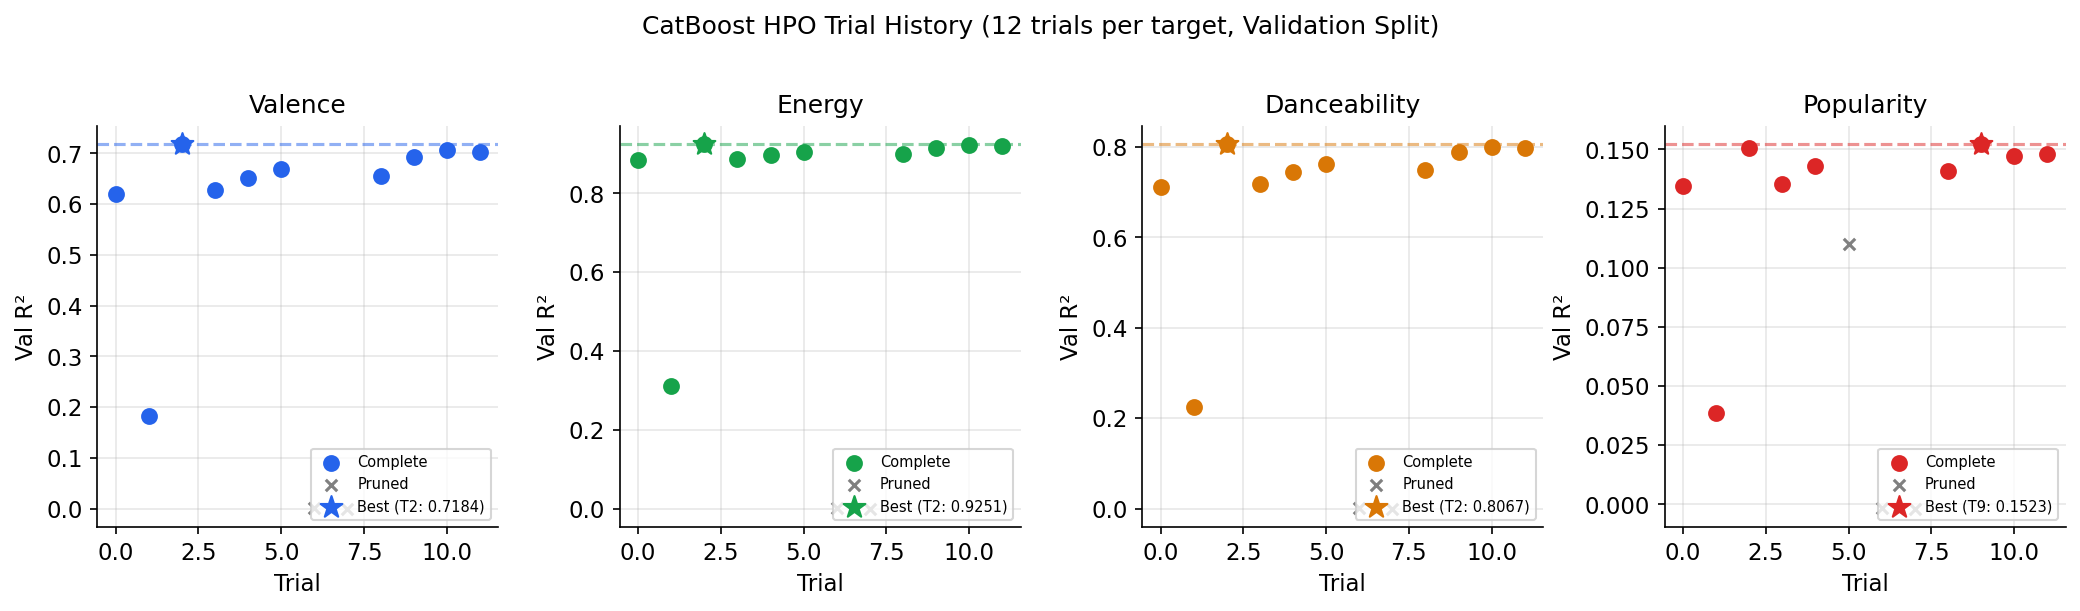

Saved: 13_catboost_hpo_trials.png


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)

colors_targets = ['#2563EB', '#16A34A', '#D97706', '#DC2626']

for ax, tgt, tgt_label, col in zip(axes, TARGETS, TARGET_LABELS, colors_targets):
    df = cb_trials[tgt]
    completed = df[df['state'] == 'COMPLETE'].copy()
    pruned    = df[df['state'] == 'PRUNED'].copy()
    
    ax.scatter(completed['number'], completed['value'], color=col, s=50, zorder=5, label='Complete')
    if len(pruned):
        ax.scatter(pruned['number'], pruned['value'].fillna(0), color='gray', s=30,
                   marker='x', zorder=4, label='Pruned')
    
    # Best trial
    best_idx = completed['value'].idxmax()
    best_row = completed.loc[best_idx]
    ax.axhline(best_row['value'], linestyle='--', color=col, alpha=0.5)
    ax.scatter(best_row['number'], best_row['value'], color=col, s=120,
               marker='*', zorder=6, label=f'Best (T{int(best_row["number"])}: {best_row["value"]:.4f})')
    
    ax.set_xlabel('Trial')
    ax.set_ylabel('Val R²')
    ax.set_title(tgt_label)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3)

fig.suptitle('CatBoost HPO Trial History (12 trials per target, Validation Split)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / '13_catboost_hpo_trials.png', bbox_inches='tight')
plt.show()
print('Saved: 13_catboost_hpo_trials.png')

## 6. Figure 5 — AttentionDL HPO Trial History

DL HPO columns: ['number', 'value', 'datetime_start', 'datetime_complete', 'duration', 'params_batch_size', 'params_dropout_enc', 'params_dropout_fusion', 'params_lr', 'params_weight_decay', 'user_attrs_best_epoch', 'user_attrs_best_val_metrics', 'user_attrs_best_val_r2', 'state']
   number     value              datetime_start           datetime_complete  \
0       0  0.629312  2026-05-28 01:18:47.207728  2026-05-28 01:42:07.098627   
1       1  0.605573  2026-05-28 01:42:07.099645  2026-05-28 02:06:52.772659   
2       2  0.631023  2026-05-28 02:06:52.773662  2026-05-28 02:23:23.731652   

                 duration  params_batch_size  params_dropout_enc  \
0  0 days 00:23:19.890899                256            0.319598   
1  0 days 00:24:45.673014                512            0.280335   
2  0 days 00:16:30.957990                512            0.154547   

   params_dropout_fusion  params_lr  params_weight_decay  \
0               0.439463   0.000141             0.036809   
1       

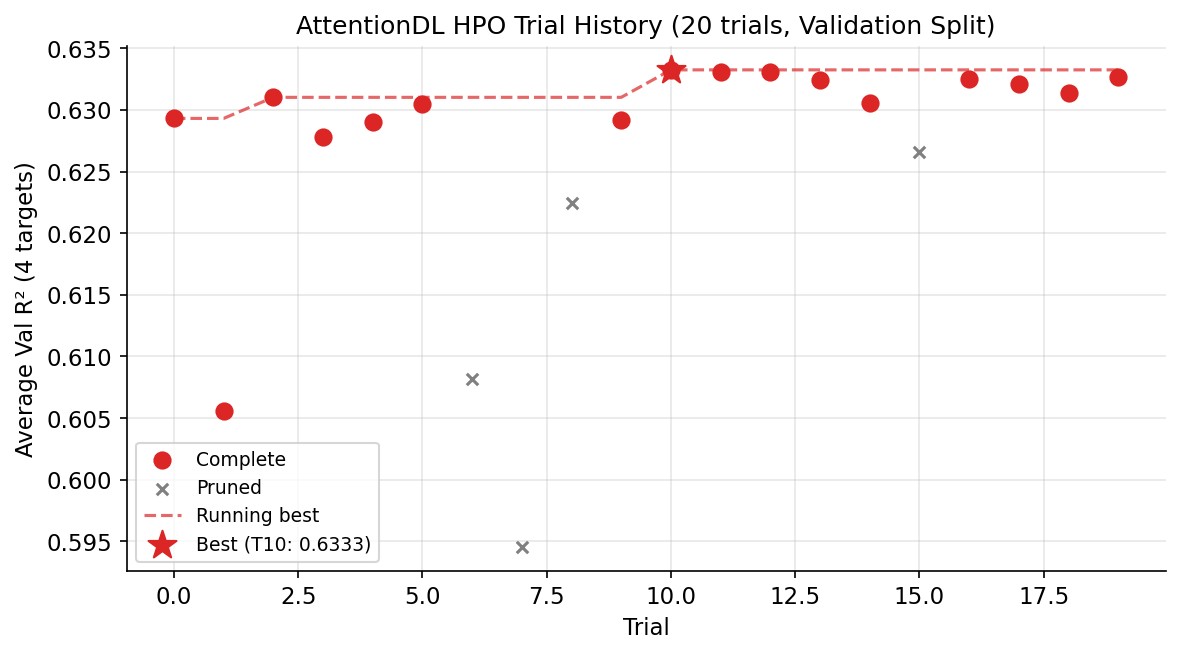

Saved: 13_attention_dl_hpo_trials.png


In [7]:
# The DL HPO CSV has trials for the AttentionDL model; value = average val R²
print('DL HPO columns:', dl_trials.columns.tolist())
print(dl_trials.head(3))

fig, ax = plt.subplots(figsize=(8, 4.5))

value_col = 'value'  # adjust if needed
state_col = 'state' if 'state' in dl_trials.columns else 'State'
num_col   = 'number' if 'number' in dl_trials.columns else 'Number'

completed = dl_trials[dl_trials[state_col] == 'COMPLETE'] if state_col in dl_trials.columns else dl_trials
pruned    = dl_trials[dl_trials[state_col] == 'PRUNED'] if state_col in dl_trials.columns else pd.DataFrame()

ax.scatter(completed[num_col], completed[value_col], color=C_DL, s=60, zorder=5, label='Complete')
if len(pruned):
    ax.scatter(pruned[num_col], pruned[value_col].fillna(0), color='gray', s=30,
               marker='x', zorder=4, label='Pruned')

# Running best
running_best = completed[value_col].cummax()
ax.plot(completed[num_col], running_best, color=C_DL, linestyle='--', alpha=0.7, label='Running best')

best_idx = completed[value_col].idxmax()
best_row = completed.loc[best_idx]
ax.scatter(best_row[num_col], best_row[value_col], color=C_DL, s=200,
           marker='*', zorder=6, label=f'Best (T{int(best_row[num_col])}: {best_row[value_col]:.4f})')

ax.set_xlabel('Trial')
ax.set_ylabel('Average Val R² (4 targets)')
ax.set_title('AttentionDL HPO Trial History (20 trials, Validation Split)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / '13_attention_dl_hpo_trials.png', bbox_inches='tight')
plt.show()
print('Saved: 13_attention_dl_hpo_trials.png')

## Summary

**Key findings from architecture and HPO analysis:**

1. **Architecture progression is monotonic on average:** Flat MLP < Multimodal Fusion < Task-Gated < Attention Task-Gated, confirming that increasingly sophisticated modality fusion improves test performance.
2. **Feat-Eng variant does not beat pure Attention on test** despite competitive validation performance.
3. **Val → Test transfer is consistent:** no signs of validation overfitting in architecture selection.
4. **HPO effect is positive but modest:** CatBoost gains +0.004 avg R², AttentionDL gains +0.005. Neither change changes the ML-vs-DL winner conclusion.
5. **CatBoost HPO converged quickly** (best at trial 2 for valence, trial 9 for popularity). Low l2_leaf_reg and moderate depth/learning_rate are consistently selected.
6. **AttentionDL HPO** identified moderate dropout (~0.21) and batch size 512 as optimal.